In [1]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder , StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [2]:
# Step 1: Load the dataset
file_path = "SP1 Season 2023-2024.csv" 
df = pd.read_csv(file_path)

# Step 2: Identify the index of the "AR" column
ar_index = df.columns.get_loc('AR')

# Step 3: Keep only columns up to and including "AR"
df = df.iloc[:, :ar_index + 1]

# Step 4: Display the first few rows to verify
df.head()



,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,SP1,11/08/2023,18:30,Almeria,Vallecano,0,2,A,0,2,...,5,4,16,25,8,3,1,3,0,0
1,SP1,11/08/2023,21:00,Sevilla,Valencia,1,2,A,0,0,...,3,3,15,17,8,1,3,2,1,0
2,SP1,12/08/2023,16:00,Sociedad,Girona,1,1,D,1,0,...,2,1,22,9,4,1,2,5,0,0
3,SP1,12/08/2023,18:30,Las Palmas,Mallorca,1,1,D,1,0,...,2,2,11,21,3,6,3,2,0,0
4,SP1,12/08/2023,20:30,Ath Bilbao,Real Madrid,0,2,A,0,2,...,1,8,18,6,7,5,3,1,0,0


In [26]:
# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (380, 23)

First 5 rows:
   Div        Date   Time    HomeTeam     AwayTeam  FTHG  FTAG FTR  HTHG  \
0  SP1  11/08/2023  18:30     Almeria    Vallecano     0     2   A     0   
1  SP1  11/08/2023  21:00     Sevilla     Valencia     1     2   A     0   
2  SP1  12/08/2023  16:00    Sociedad       Girona     1     1   D     1   
3  SP1  12/08/2023  18:30  Las Palmas     Mallorca     1     1   D     1   
4  SP1  12/08/2023  20:30  Ath Bilbao  Real Madrid     0     2   A     0   

   HTAG  ... HST  AST  HF  AF  HC  AC  HY  AY  HR  AR  
0     2  ...   5    4  16  25   8   3   1   3   0   0  
1     0  ...   3    3  15  17   8   1   3   2   1   0  
2     0  ...   2    1  22   9   4   1   2   5   0   0  
3     0  ...   2    2  11  21   3   6   3   2   0   0  
4     2  ...   1    8  18   6   7   5   3   1   0   0  

[5 rows x 23 columns]

Columns: ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'H

# Data Exploration

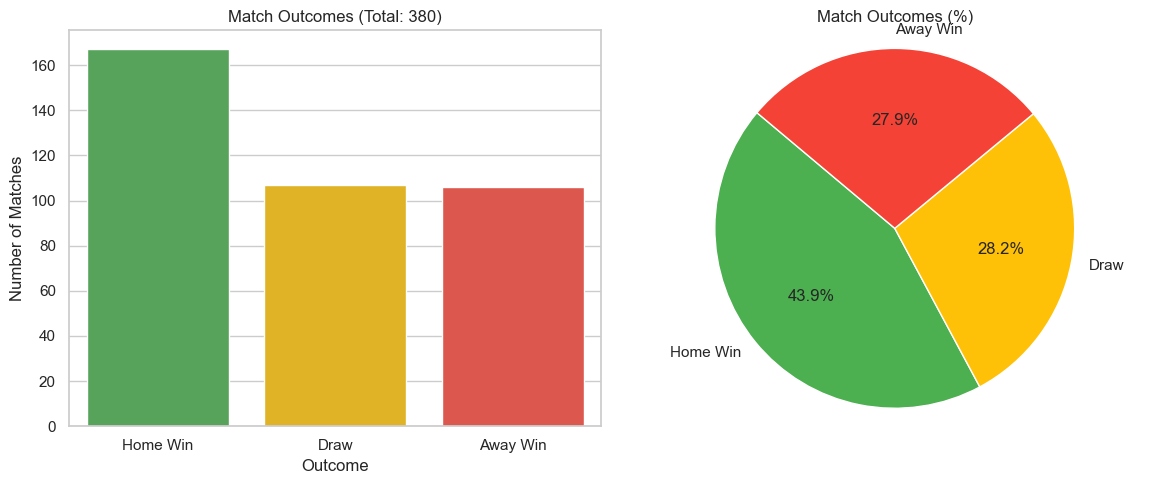

In [27]:
# Count outcomes
outcome_counts = df['FTR'].value_counts().sort_index()  # H, D, A
labels = ['Home Win', 'Draw', 'Away Win']
counts = [outcome_counts.get('H', 0), outcome_counts.get('D', 0), outcome_counts.get('A', 0)]
colors = ['#4CAF50', '#FFC107', '#F44336']
total_games = sum(counts)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.set(style="whitegrid")

# Bar Chart
sns.barplot(ax=axes[0], x=labels, y=counts, palette=colors)
axes[0].set_title(f'Match Outcomes (Total: {total_games})')
axes[0].set_ylabel('Number of Matches')
axes[0].set_xlabel('Outcome')

# Pie Chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Match Outcomes (%)')
axes[1].axis('equal')  # Equal aspect ratio

plt.tight_layout()
plt.show()

In [28]:
# Count outcomes
outcome_counts = df['FTR'].value_counts().sort_index()  

# Rename for clarity
home_wins = outcome_counts.get('H', 0)
draws = outcome_counts.get('D', 0)
away_wins = outcome_counts.get('A', 0)
total_games = home_wins + draws + away_wins


# Print results
print(f"Total Games Played: {total_games}")
print(f"Home Wins (H): {home_wins}")
print(f"Draws (D): {draws}")
print(f"Away Wins (A): {away_wins}")


Total Games Played: 380
Home Wins (H): 167
Draws (D): 107
Away Wins (A): 106


Overall, the data indicates that home wins are the most frequent outcome, followed by away wins, with draws being the least common.

Total Home Goals: 564 | Average: 1.48
Total Away Goals: 441 | Average: 1.16


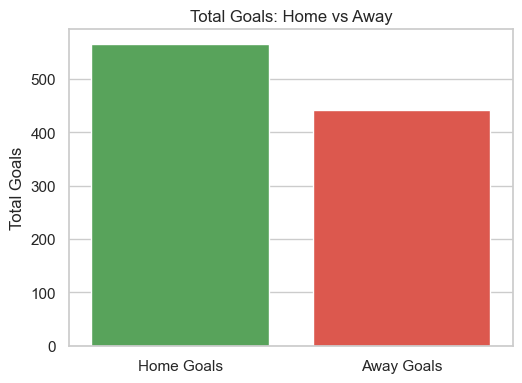

In [29]:
# Calculate totals and means
home_goals = df['FTHG'].sum()
away_goals = df['FTAG'].sum()
home_avg = df['FTHG'].mean()
away_avg = df['FTAG'].mean()

print(f"Total Home Goals: {home_goals} | Average: {home_avg:.2f}")
print(f"Total Away Goals: {away_goals} | Average: {away_avg:.2f}")

# Bar chart: total goals
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(x=['Home Goals', 'Away Goals'], y=[home_goals, away_goals], palette=['#4CAF50', '#F44336'])
plt.title('Total Goals: Home vs Away')
plt.ylabel('Total Goals')
 
plt.tight_layout()
plt.show()


Teams tend to score goal when playing home compared to away 

Total Goals Per Match:
count    380.000000
mean       2.644737
std        1.772734
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        8.000000
Name: TotalGoals, dtype: float64


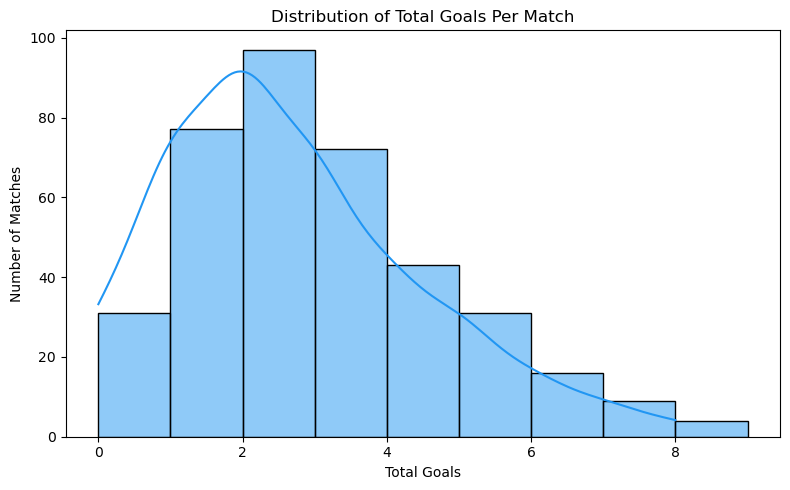

In [3]:
# Descriptive stats
print("Total Goals Per Match:")
print(df['TotalGoals'].describe())

# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalGoals'], bins=range(0, df['TotalGoals'].max() + 2), kde=True, color="#2196F3")
plt.title('Distribution of Total Goals Per Match')
plt.xlabel('Total Goals')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()


In [30]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid overwriting original
df_encoded = df.copy()

# Initialize label encoder
le = LabelEncoder()

# Identify non-numeric (object or category) columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

# Apply label encoding to each categorical column
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))  # Handle NaNs as strings safely

print("Encoded Columns:", categorical_cols)
print(df_encoded[categorical_cols].head())


Encoded Columns: ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTR', 'HTR']
   Div  Date  Time  HomeTeam  AwayTeam  FTR  HTR
0    0    46     7         1        18    0    0
1    0    46    11        15        17    0    1
2    0    53     2        16         9    1    2
3    0    53     7        11        12    1    2
4    0    53    10         2        14    0    0


In [31]:
df_encoded

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,0,46,7,1,18,0,2,0,0,2,...,5,4,16,25,8,3,1,3,0,0
1,0,46,11,15,17,1,2,0,0,0,...,3,3,15,17,8,1,3,2,1,0
2,0,53,2,16,9,1,1,1,1,0,...,2,1,22,9,4,1,2,5,0,0
3,0,53,7,11,12,1,1,1,1,0,...,2,2,11,21,3,6,3,2,0,0
4,0,53,10,2,14,0,2,0,0,2,...,1,8,18,6,7,5,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,0,111,9,14,5,0,0,1,0,0,...,5,3,8,11,4,5,2,1,0,0
376,0,117,0,8,12,1,2,0,0,0,...,6,4,12,10,3,4,0,2,0,0
377,0,117,1,7,17,2,2,1,0,1,...,4,1,17,18,2,2,0,0,0,0
378,0,117,1,11,0,1,1,1,0,0,...,4,4,16,10,2,6,2,1,0,0


# Feature importance 

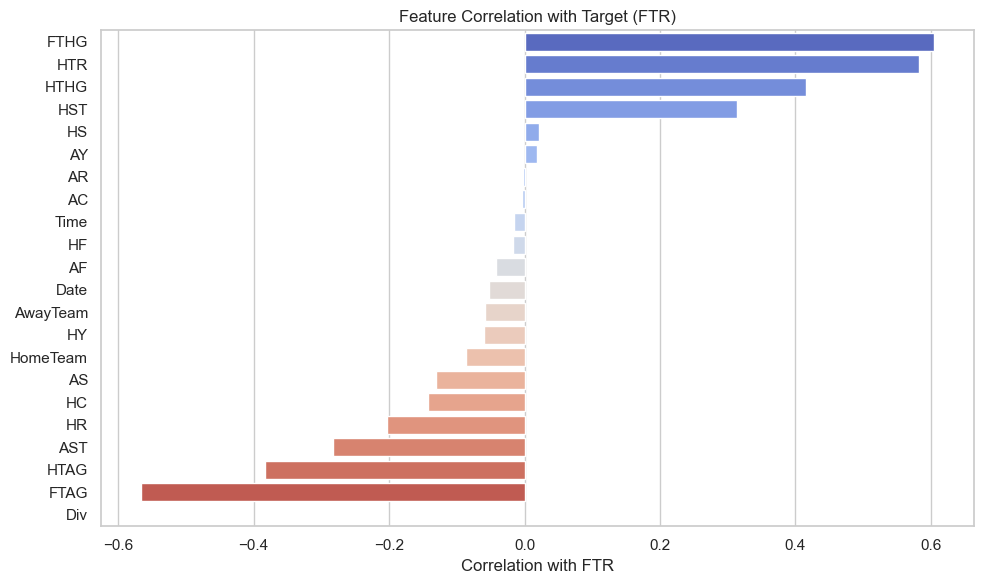

In [32]:
# Compute correlation matrix
corr_matrix = df_encoded.corr()

# Correlation of features with target
target_corr = corr_matrix['FTR'].drop('FTR').sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Feature Correlation with Target (FTR)')
plt.xlabel('Correlation with FTR')
plt.tight_layout()
plt.show()


In [33]:
#  Compute correlation with target
correlation_threshold = 0.05  
corr_matrix = df_encoded.corr()
target_corr = corr_matrix['FTR'].drop('FTR')  #Exclude target itself

# Step 2: Identify relevant features (those with correlation above threshold)
relevant_features = target_corr[abs(target_corr) >= correlation_threshold].index.tolist()

# Step 3: Keep only relevant features + target
df_selected = df_encoded[relevant_features + ['FTR']]

print(" Features retained based on correlation with FTR:")
print(relevant_features)


 Features retained based on correlation with FTR:
['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'HTHG', 'HTAG', 'HTR', 'AS', 'HST', 'AST', 'HC', 'HY', 'HR']


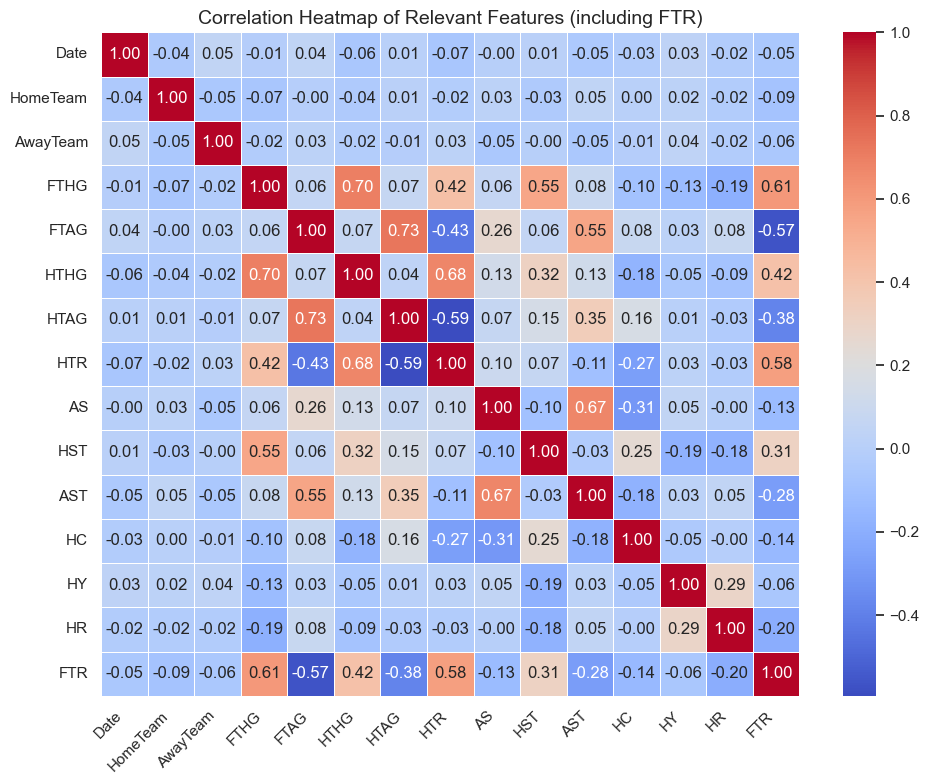

In [34]:
corr = df_selected.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Relevant Features (including FTR)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Models

In [35]:
df_model = df_selected.copy()

In [36]:
# Features and target
X = df_model.drop('FTR', axis=1)
y = df_model['FTR']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [37]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


🔹 Random Forest (Before Tuning, With Standardization):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        21
           1       0.87      0.91      0.89        22
           2       1.00      0.97      0.98        33

    accuracy                           0.93        76
   macro avg       0.92      0.93      0.93        76
weighted avg       0.94      0.93      0.93        76

Accuracy: 0.9342105263157895


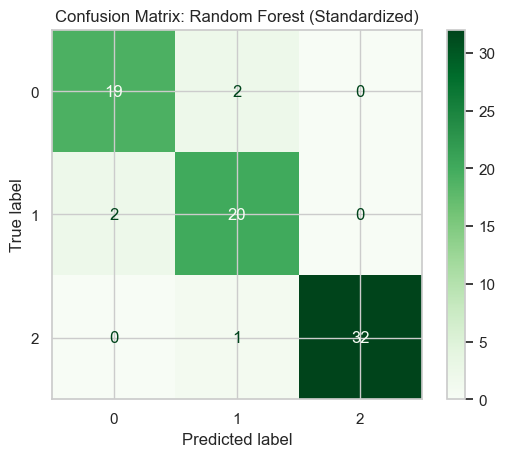

In [38]:
# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)


y_pred_rf = rf_model.predict(X_test_scaled)


print("🔹 Random Forest (Before Tuning, With Standardization):")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap='Greens')
plt.title("Confusion Matrix: Random Forest (Standardized)")
plt.show()


In [39]:

# Initialize XGBClassifier with default settings
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train on standardized data
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)


🔸 XGBoost Classifier (Before Tuning, With Standardization):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.95      0.98        22
           2       0.97      1.00      0.99        33

    accuracy                           0.99        76
   macro avg       0.99      0.98      0.99        76
weighted avg       0.99      0.99      0.99        76

Accuracy: 0.9868421052631579


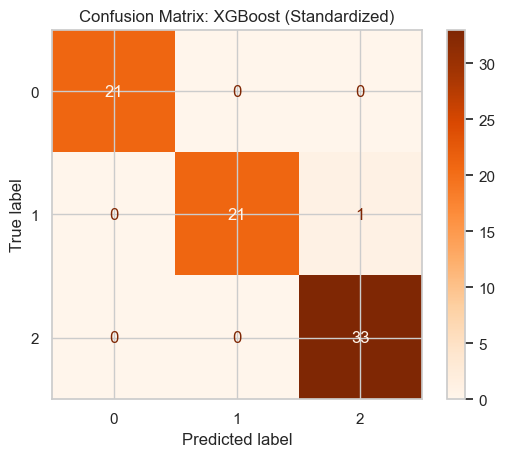

In [40]:
# Evaluation report
print("🔸 XGBoost Classifier (Before Tuning, With Standardization):")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_model.classes_)
disp_xgb.plot(cmap='Oranges')
plt.title("Confusion Matrix: XGBoost (Standardized)")
plt.show()


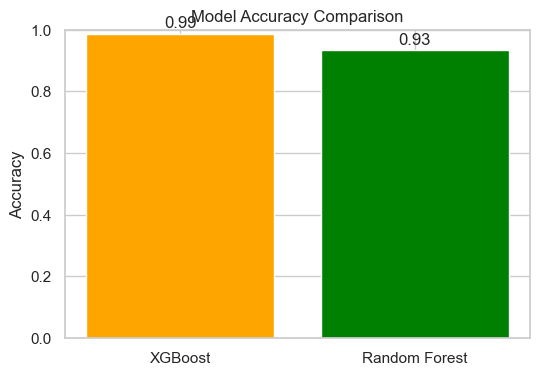

In [41]:
# Calculate accuracy scores first
acc_xgb = accuracy_score(y_test, y_pred_xgb)
acc_rf = accuracy_score(y_test, y_pred_rf)

# Model names and accuracy values
models = ['XGBoost', 'Random Forest']
accuracies = [acc_xgb, acc_rf]

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=['orange', 'green'])
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.show()


# Paramter tuning

XGBoost 

In [46]:
# Define parameter grid
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Initialize the model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Grid search
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=5,
    n_jobs=1,             
    verbose=1,
    scoring='accuracy'
)

xgb_grid.fit(X_train_scaled, y_train)

# Best model
best_xgb = xgb_grid.best_estimator_
print("🔸 Best XGBoost Parameters:", xgb_grid.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
🔸 Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0}


Random Forest 

In [49]:

# Define parameter grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize the model
rf = RandomForestClassifier()

# Grid search
# Grid search (FIXED)
rf_grid = GridSearchCV(estimator=rf, param_grid=rf_param_grid, 
                       cv=5, n_jobs=1, verbose=1, scoring='accuracy')
rf_grid.fit(X_train_scaled, y_train)

# Best model
best_rf = rf_grid.best_estimator_

print("🔹 Best Random Forest Parameters:", rf_grid.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
🔹 Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}



🔸 XGBoost (After Tuning):
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.95      0.98        22
           2       1.00      1.00      1.00        33

    accuracy                           0.99        76
   macro avg       0.98      0.98      0.98        76
weighted avg       0.99      0.99      0.99        76

Accuracy: 0.9868421052631579

🔹 Random Forest (After Tuning):
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        21
           1       0.84      0.95      0.89        22
           2       0.97      0.94      0.95        33

    accuracy                           0.93        76
   macro avg       0.94      0.93      0.93        76
weighted avg       0.94      0.93      0.94        76

Accuracy: 0.9342105263157895


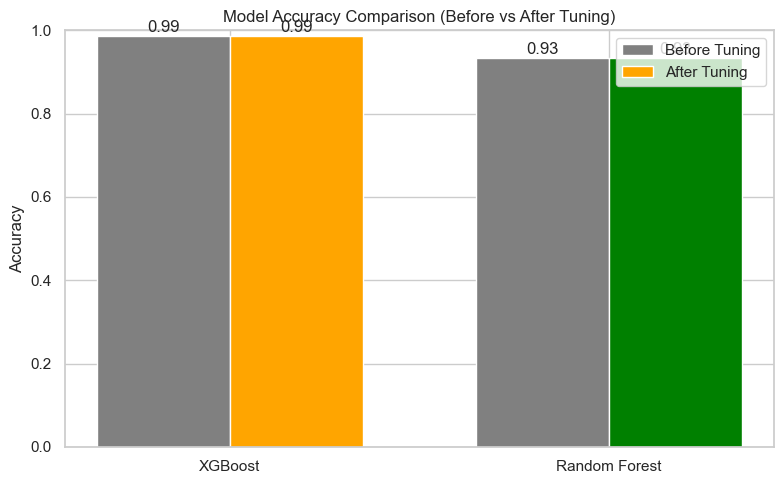

In [51]:
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Predict
y_pred_best_xgb = best_xgb.predict(X_test_scaled)
y_pred_best_rf = best_rf.predict(X_test_scaled)

# Calculate accuracy scores
acc_xgb_after = accuracy_score(y_test, y_pred_best_xgb)
acc_rf_after = accuracy_score(y_test, y_pred_best_rf)


# Evaluate
print("\n🔸 XGBoost (After Tuning):")
print(classification_report(y_test, y_pred_best_xgb))
print("Accuracy:", acc_xgb_after)

print("\n🔹 Random Forest (After Tuning):")
print(classification_report(y_test, y_pred_best_rf))
print("Accuracy:", acc_rf_after)

# Plotting
labels = ['XGBoost', 'Random Forest']
before_tuning = [acc_xgb, acc_rf]  # Make sure these are defined
after_tuning = [acc_xgb_after, acc_rf_after]

x = range(len(labels))
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, before_tuning, width=bar_width, label='Before Tuning', color='gray')
plt.bar([i + bar_width for i in x], after_tuning, width=bar_width, label='After Tuning', color=['orange', 'green'])

# Add value labels
for i in range(len(labels)):
    plt.text(i, before_tuning[i] + 0.01, f"{before_tuning[i]:.2f}", ha='center')
    plt.text(i + bar_width, after_tuning[i] + 0.01, f"{after_tuning[i]:.2f}", ha='center')

plt.xticks([i + bar_width / 2 for i in x], labels)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Before vs After Tuning)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()